In [1]:
!pip install -Uqq fastai

In [1]:
from fastai.data.all import *
from fastai.vision.all import *


Downloading the datas of pets

In [2]:
path = untar_data(URLs.PETS)
path

<div><progress max="811706944" value="811712512"></progress> 100.00% [811712512/811706944 00:25&lt;00:00]</div>

Path('/root/.fastai/data/oxford-iiit-pet')

storing all the images of cats and dogs  inside the var called fnames

In [17]:
fnames = get_image_files(path/'images')
fnames[0]

Path('/root/.fastai/data/oxford-iiit-pet/images/beagle_115.jpg')

In [7]:
def label_func(fname):
    return 'cat' if fname.name[0].isupper() else 'dog'
    

In [8]:
dblock = DataBlock(
    get_items = get_image_files ,   #the training data source
    get_y = label_func  #the target function that separates whether the image is dog or cat
)


In [9]:
datasets = dblock.datasets(path/'images')
datasets[0]

(Path('/root/.fastai/data/oxford-iiit-pet/images/beagle_115.jpg'), 'dog')

In [18]:
dblock = DataBlock(
    blocks = (ImageBlock,CategoryBlock),   #categorizing the job of a model
    get_items = get_image_files ,   #the training data source
    get_y = label_func,  #the target function that separates whether the image is dog or cat
    splitter = RandomSplitter(valid_pct = 0.2 , seed = 42),  #splitting into training as well as test dataset
    item_tfms = [Resize(192, method = 'squish')]  #transforming the image or resizing
)


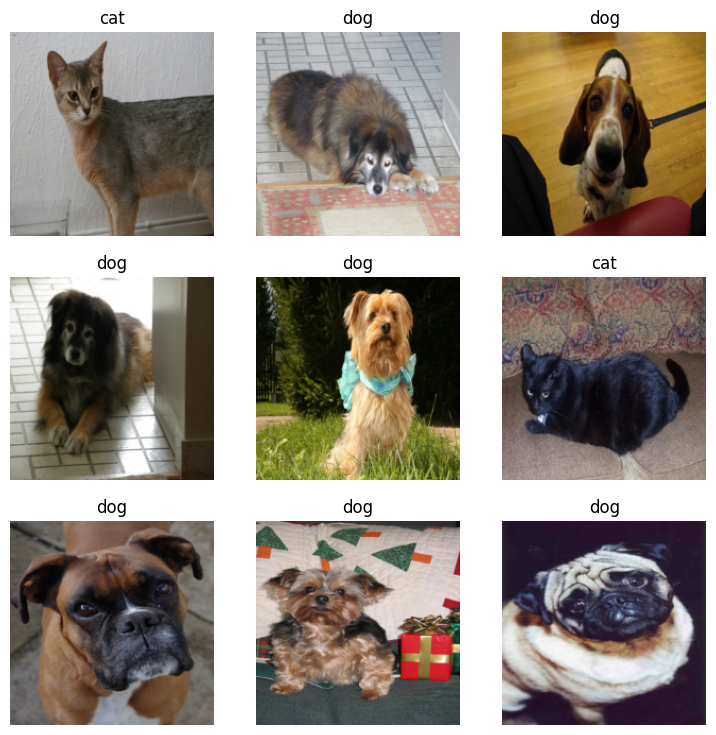

In [20]:
dls = dblock.dataloaders(path/'images')
dls.show_batch()

In [22]:
learn = vision_learner(dls,resnet18, metrics = error_rate)  #we are using NN called resnet18 
learn.fine_tune(3) #fine tuning the model

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 201MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,0.208388,0.101637,0.032476,00:18


epoch,train_loss,valid_loss,error_rate,time
0,0.078612,0.094255,0.027064,00:18
1,0.027116,0.034491,0.012179,00:18
2,0.013199,0.042972,0.011502,00:18


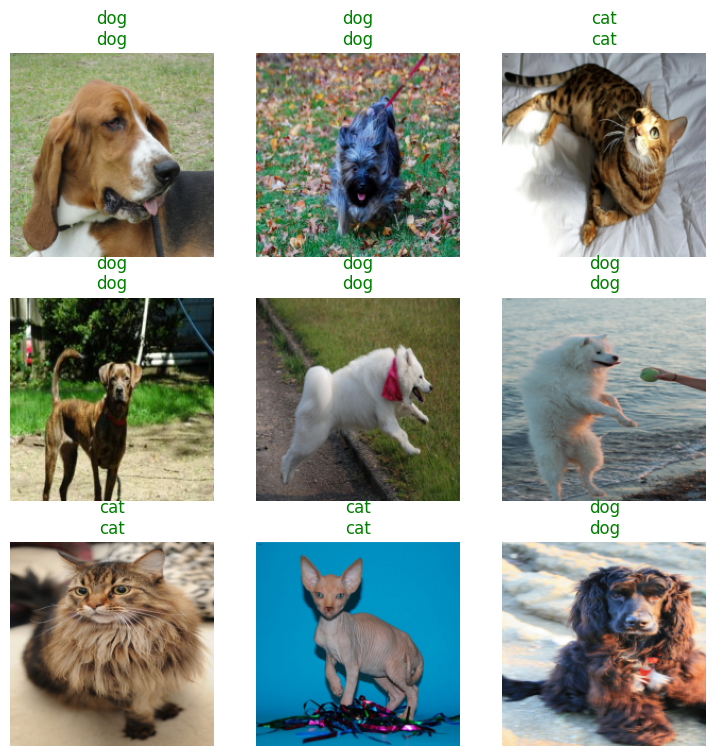

In [25]:
learn.predict(fnames[6])
learn.show_results()